# 04. Generator diagnostics and source--sink decomposition

This notebook diagnoses the failure of the null model and reconstructs the empirical source--sink balance $\dot\sigma=2A\cos\alpha+R_\sigma$ from the enriched train.


# Ellipsoid generator diagnostics v11

This notebook diagnoses why the first SDE calibration failed to reproduce the empirical MEE aspect-ratio dynamics.

The empirical object is fixed throughout:

$$(M,g)=(M^{(\mathrm{avg;out})},g^{(\mathrm{out})}).$$

The question here is not yet how to build the final reduced model.  The question is more basic:

**What empirical source creates and maintains $\sigma=O(1)$?**

The previous marginal-OU SDE used the equation

$$\dot\sigma = 2S'_{11} - \frac12 \kappa(r)\sinh(2\sigma),$$

but generated $M$ independently of the current ellipsoid geometry.  This notebook checks whether the empirical data contain a nonzero conditional source

$$2S'_{11}=2\big(s_+\cos 2\theta_g+s_\times\sin 2\theta_g\big)$$

and whether this source is explained by alignment between the ellipsoid axis and the principal strain direction.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from scipy import stats

plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 10,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 120,
})

DATA = Path('empirical_train_mavg_out_v10b_enriched.npz')
CAL = Path('sde_calibration_mavg_out_v10_results.npz')
FIGDIR = Path('/mnt/data/figs_generator_diagnostics_v11')
FIGDIR.mkdir(exist_ok=True)

assert DATA.exists(), f'Missing empirical file: {DATA}'
assert CAL.exists(), f'Missing calibration file: {CAL}'

z = np.load(DATA, allow_pickle=True)
c = np.load(CAL, allow_pickle=True)

print('Empirical keys:', z.files)
print('Calibration keys:', c.files)

Empirical keys: ['times', 'M', 'g', 'r_edges', 'r_centers', 'bin_idx', 's_plus', 's_cross', 'omega', 'v', 'sigma', 'theta_g', 'theta_s', 'r', 'sigma_mean', 'sigma_sem_seed', 'chi', 'chi_sem_seed', 'M2_red_mean', 'M2_red_sem_seed', 'M2_red_slope', 'M2_red_slope_se', 'alignment_mean', 'alignment_sem_seed']
Calibration keys: ['r_edges', 'r_centers', 'dt', 'lag_steps', 'lag_dt', 'C0', 'Cd', 'rho', 'tau_comp', 'D_comp', 'tau_s', 'D_s', 'tau_w', 'D_w', 'gamma', 'gamma_sem', 'kappa_raw', 'kappa_sem_seed', 'kappa_nonneg', 'emp_sigma_mean', 'emp_chi', 'emp_M2_red_mean', 'M0_sigma_mean', 'M0_chi', 'M0_M2_red_mean', 'M1_sigma_mean', 'M1_chi', 'M1_M2_red_mean']


## 1. Load the empirical train and define derived quantities

The enriched empirical file already contains $s_+$, $s_\times$, $\omega$, $v$, $\sigma$, $\theta_g$, $\theta_S$, and $r$.  We recompute the strain-frame source term directly as

$$S'_{11}=s_+\cos 2\theta_g+s_\times\sin 2\theta_g.$$

Equivalently, if $|S|=\sqrt{s_+^2+s_\times^2}$ and $\alpha=2(\theta_S-\theta_g)$, then

$$S'_{11}=|S|\cos\alpha.$$

This identity is useful because it separates the source into strain amplitude and alignment.

In [2]:
times = z['times']
dt = float(np.median(np.diff(times)))

s_plus = z['s_plus']
s_cross = z['s_cross']
omega = z['omega']
v = z['v']
sigma = z['sigma']
theta_g = z['theta_g']
theta_s = z['theta_s']
r = z['r']

r_edges = z['r_edges']
r_centers = z['r_centers']
n_bins = len(r_centers)

# Empirical source in the ellipsoid frame.
S_abs = np.sqrt(s_plus**2 + s_cross**2)
S11p_direct = s_plus*np.cos(2*theta_g) + s_cross*np.sin(2*theta_g)
alpha = 2*(theta_s - theta_g)
# Wrap only for visual interpretability; cos(alpha) is invariant.
alpha_wrapped = np.angle(np.exp(1j*alpha))
cos_alpha = np.cos(alpha)
S11p_alignment = S_abs*cos_alpha

print('dt =', dt)
print('shapes: sigma', sigma.shape, 'r', r.shape, 'M components', s_plus.shape)
print('identity check max |S11 direct - |S|cos alpha| =', np.nanmax(np.abs(S11p_direct - S11p_alignment)))
print('r range:', np.nanmin(r), np.nanmax(r))
print('sigma range:', np.nanmin(sigma), np.nanmax(sigma))

dt = 0.009999999999999787
shapes: sigma (12, 1501) r (12, 1501) M components (12, 1501)
identity check max |S11 direct - |S|cos alpha| = 9.992007221626409e-16
r range: 0.2060030009767877 2.3104696955516695
sigma range: 0.0020355506816782535 2.256825154119682


## 2. Central-difference empirical tendencies

We estimate tendencies using centered finite differences.  The diagnostic variables are evaluated at the midpoint index $1,\ldots,T-1$:

$$\dot\sigma(t_i) \approx \frac{\sigma(t_{i+1})-\sigma(t_{i-1})}{2\Delta t},$$

$$\dot v(t_i) \approx \frac{v(t_{i+1})-v(t_{i-1})}{2\Delta t}.$$

The empirical residual in the aspect-ratio equation is

$$R_\sigma=\dot\sigma-2S'_{11}.$$

If the previous SDE closure were adequate, $R_\sigma$ would be mostly explained by

$$-\frac12\kappa(r)\sinh(2\sigma).$$

In [3]:
# Central differences, aligned to the interior time grid.
sigma_dot = (sigma[:,2:] - sigma[:,:-2])/(2*dt)
v_dot = (v[:,2:] - v[:,:-2])/(2*dt)

# Interior-aligned state variables.
r_m = r[:,1:-1]
sigma_m = sigma[:,1:-1]
v_m = v[:,1:-1]
s_plus_m = s_plus[:,1:-1]
s_cross_m = s_cross[:,1:-1]
omega_m = omega[:,1:-1]
S_abs_m = S_abs[:,1:-1]
S11p_m = S11p_direct[:,1:-1]
cos_alpha_m = cos_alpha[:,1:-1]
alpha_m = alpha_wrapped[:,1:-1]

source_sigma = 2*S11p_m
R_sigma = sigma_dot - source_sigma

# Interpolate fitted gamma and kappa from previous calibration.
gamma_bins = c['gamma']
kappa_bins = c['kappa_nonneg']
gamma_m = np.interp(r_m, r_centers, gamma_bins, left=gamma_bins[0], right=gamma_bins[-1])
kappa_m = np.interp(r_m, r_centers, kappa_bins, left=kappa_bins[0], right=kappa_bins[-1])

vol_model = -0.5*gamma_m
sigma_sink = 0.5*kappa_m*np.sinh(2*sigma_m)  # positive quantity; contribution is -sigma_sink

print('central arrays:', sigma_dot.shape, source_sigma.shape, R_sigma.shape)
print('mean sigma_dot:', np.nanmean(sigma_dot))
print('mean 2S11p:', np.nanmean(source_sigma))
print('mean R_sigma:', np.nanmean(R_sigma))
print('mean fitted sink:', np.nanmean(sigma_sink))

central arrays: (12, 1499) (12, 1499) (12, 1499)
mean sigma_dot: 0.03982563904275265
mean 2S11p: 0.23235971568901406
mean R_sigma: -0.1925340766462614
mean fitted sink: 0.15180638746272962


## 3. Helper functions for binning and seed-level uncertainty

We report seed-level uncertainties whenever possible.  This is more honest than treating all time samples as independent, because the time series is strongly correlated.

In [4]:
def bin_index(x):
    return np.digitize(x, r_edges) - 1

def binned_mean_flat(x, values):
    idx = bin_index(x)
    means = np.full(n_bins, np.nan)
    counts = np.zeros(n_bins, dtype=int)
    for k in range(n_bins):
        sel = (idx == k) & np.isfinite(values)
        counts[k] = np.count_nonzero(sel)
        if counts[k] > 0:
            means[k] = np.nanmean(values[sel])
    return means, counts

def binned_seed_mean(x, values):
    """Return mean across seeds and SEM across seed-level bin means."""
    nseed = x.shape[0]
    per_seed = np.full((nseed, n_bins), np.nan)
    counts = np.zeros((nseed, n_bins), dtype=int)
    for a in range(nseed):
        idx = bin_index(x[a])
        for k in range(n_bins):
            sel = (idx == k) & np.isfinite(values[a])
            counts[a,k] = np.count_nonzero(sel)
            if counts[a,k] > 0:
                per_seed[a,k] = np.nanmean(values[a,sel])
    mean = np.nanmean(per_seed, axis=0)
    sem = np.nanstd(per_seed, axis=0, ddof=1)/np.sqrt(np.sum(np.isfinite(per_seed), axis=0))
    return mean, sem, per_seed, counts

def savefig(name):
    p = FIGDIR / name
    plt.tight_layout()
    plt.savefig(p.with_suffix('.png'), dpi=220, bbox_inches='tight')
    plt.savefig(p.with_suffix('.pdf'), bbox_inches='tight')
    print('saved', p.with_suffix('.png'))

# Basic bin population for the midpoint arrays.
_, counts_mid = binned_mean_flat(r_m.ravel(), sigma_m.ravel())
print('midpoint bin counts:', counts_mid)

midpoint bin counts: [1536 1705 1981 3014 3819 3076 1346]


## 4. Source-residual budget for $\sigma$

The central diagnostic is the empirical budget

$$\dot\sigma = 2S'_{11}+R_\sigma.$$

We compare four terms by $r$-bin:

$$\langle\dot\sigma\mid r\rangle,$$

$$\langle 2S'_{11}\mid r\rangle,$$

$$\langle R_\sigma\mid r\rangle,$$

and the fitted nonlinear damping contribution

$$-\left\langle \frac12\kappa(r)\sinh(2\sigma)\mid r\right\rangle.$$

A positive $\langle 2S'_{11}\mid r\rangle$ is the missing mechanism in the independent marginal-OU SDE.

r_centers
[0.31441723 0.41929057 0.55914423 0.74564584 0.99435474 1.32602008
 1.76831183]
mean sigma
[1.0320443  1.08424356 1.11699837 1.04399789 1.03474263 0.83130819
 0.83511541]
mean sigma_dot
[ 0.02950825 -0.06021105  0.08260922  0.00418427 -0.03627772 -0.13306972
 -0.14630067]
mean 2S11p source
[0.55399119 0.36772268 0.39747208 0.23698194 0.14321277 0.06577632
 0.03599622]
mean residual R_sigma
[-0.52448294 -0.42793372 -0.31486286 -0.23279767 -0.17949048 -0.19884604
 -0.18229689]
mean fitted positive sink
[0.38777259 0.25928551 0.22156117 0.13622687 0.1379204  0.11618167
 0.13745486]


saved /mnt/data/figs_generator_diagnostics_v11/sigma_budget_by_r.png


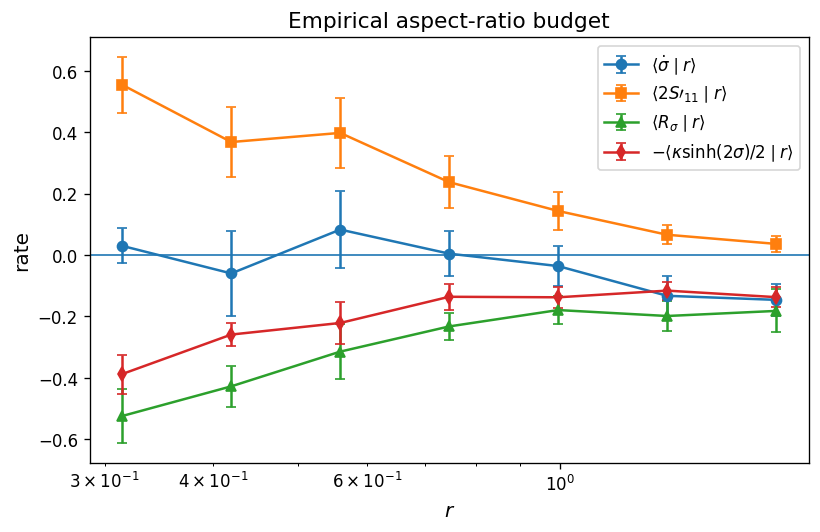

In [5]:
mean_sdot, sem_sdot, _, _ = binned_seed_mean(r_m, sigma_dot)
mean_source, sem_source, _, _ = binned_seed_mean(r_m, source_sigma)
mean_resid, sem_resid, _, _ = binned_seed_mean(r_m, R_sigma)
mean_sink, sem_sink, _, _ = binned_seed_mean(r_m, sigma_sink)
mean_sigma, sem_sigma, _, _ = binned_seed_mean(r_m, sigma_m)

print('r_centers')
print(r_centers)
print('mean sigma')
print(mean_sigma)
print('mean sigma_dot')
print(mean_sdot)
print('mean 2S11p source')
print(mean_source)
print('mean residual R_sigma')
print(mean_resid)
print('mean fitted positive sink')
print(mean_sink)

plt.figure(figsize=(7.0,4.6))
plt.axhline(0, linewidth=1)
plt.errorbar(r_centers, mean_sdot, yerr=sem_sdot, marker='o', capsize=3, label=r'$\langle \dot\sigma\mid r\rangle$')
plt.errorbar(r_centers, mean_source, yerr=sem_source, marker='s', capsize=3, label=r'$\langle 2S\prime_{11}\mid r\rangle$')
plt.errorbar(r_centers, mean_resid, yerr=sem_resid, marker='^', capsize=3, label=r'$\langle R_\sigma\mid r\rangle$')
plt.errorbar(r_centers, -mean_sink, yerr=sem_sink, marker='d', capsize=3, label=r'$-\langle \kappa\sinh(2\sigma)/2\mid r\rangle$')
plt.xscale('log')
plt.xlabel(r'$r$')
plt.ylabel('rate')
plt.title('Empirical aspect-ratio budget')
plt.legend()
savefig('sigma_budget_by_r')
plt.show()

## 5. Alignment decomposition of the source

The source can be decomposed as

$$2S'_{11}=2|S|\cos\alpha,$$

where

$$\alpha=2(\theta_S-\theta_g).$$

Thus a nonzero source may arise from strain amplitude, from alignment, or from correlations between the two.  We therefore plot

$$\langle |S|\mid r\rangle,$$

$$\langle \cos\alpha\mid r\rangle,$$

and

$$\langle 2|S|\cos\alpha\mid r\rangle.$$

mean |S|: [0.60224275 0.45774821 0.43154737 0.3242841  0.23087078 0.15003076
 0.10437921]
mean cos alpha: [0.42668657 0.29108909 0.39877335 0.28815208 0.1886296  0.1747842
 0.01517272]
mean 2|S|cos alpha: [0.55399119 0.36772268 0.39747208 0.23698194 0.14321277 0.06577632
 0.03599622]


saved /mnt/data/figs_generator_diagnostics_v11/alignment_by_r.png


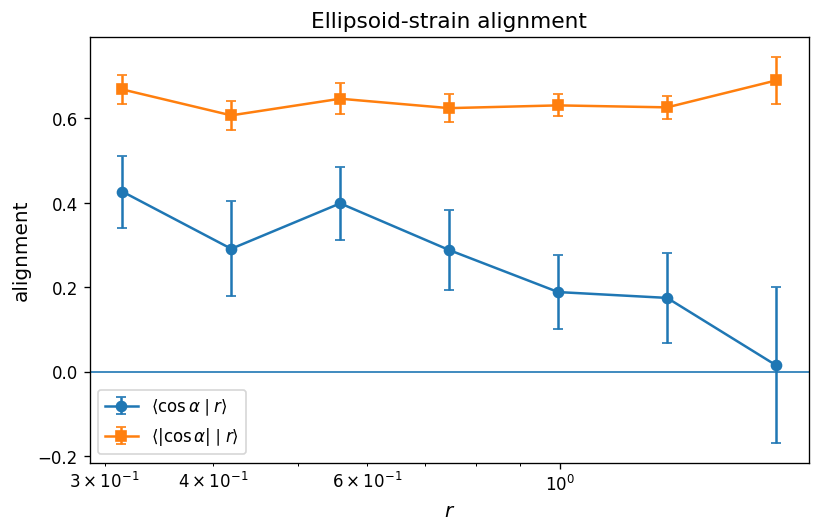

saved /mnt/data/figs_generator_diagnostics_v11/source_decomposition_by_r.png


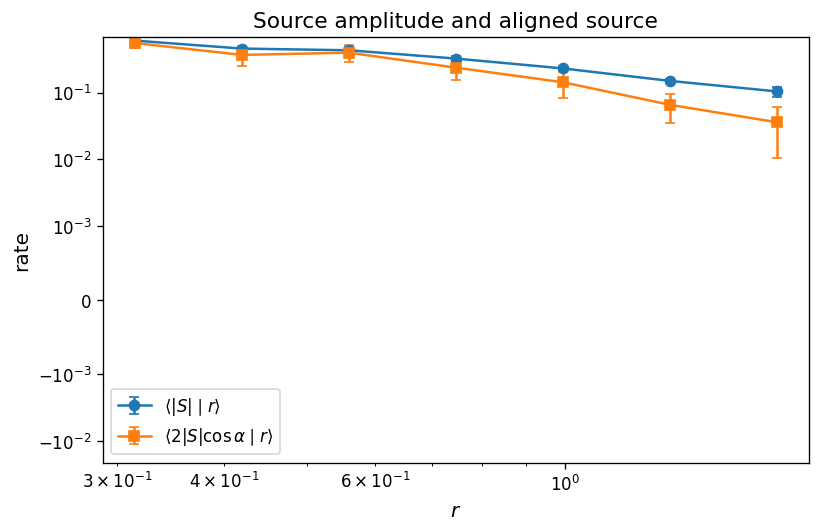

In [6]:
mean_Sabs, sem_Sabs, _, _ = binned_seed_mean(r_m, S_abs_m)
mean_cosa, sem_cosa, _, _ = binned_seed_mean(r_m, cos_alpha_m)
mean_2Scos, sem_2Scos, _, _ = binned_seed_mean(r_m, 2*S_abs_m*cos_alpha_m)
mean_abs_cosa, sem_abs_cosa, _, _ = binned_seed_mean(r_m, np.abs(cos_alpha_m))

print('mean |S|:', mean_Sabs)
print('mean cos alpha:', mean_cosa)
print('mean 2|S|cos alpha:', mean_2Scos)

plt.figure(figsize=(7.0,4.6))
plt.axhline(0, linewidth=1)
plt.errorbar(r_centers, mean_cosa, yerr=sem_cosa, marker='o', capsize=3, label=r'$\langle\cos\alpha\mid r\rangle$')
plt.errorbar(r_centers, mean_abs_cosa, yerr=sem_abs_cosa, marker='s', capsize=3, label=r'$\langle|\cos\alpha|\mid r\rangle$')
plt.xscale('log')
plt.xlabel(r'$r$')
plt.ylabel('alignment')
plt.title('Ellipsoid-strain alignment')
plt.legend()
savefig('alignment_by_r')
plt.show()

plt.figure(figsize=(7.0,4.6))
plt.errorbar(r_centers, mean_Sabs, yerr=sem_Sabs, marker='o', capsize=3, label=r'$\langle |S|\mid r\rangle$')
plt.errorbar(r_centers, mean_2Scos, yerr=sem_2Scos, marker='s', capsize=3, label=r'$\langle2|S|\cos\alpha\mid r\rangle$')
plt.xscale('log')
plt.yscale('symlog', linthresh=1e-3)
plt.xlabel(r'$r$')
plt.ylabel('rate')
plt.title('Source amplitude and aligned source')
plt.legend()
savefig('source_decomposition_by_r')
plt.show()

## 6. Direct drift $b_\sigma(r,\sigma)$

The previous closure assumes that the only explicit $\sigma$-dependence in the drift is damping:

$$-\frac12\kappa(r)\sinh(2\sigma).$$

We now estimate the empirical drift surface

$$b_\sigma(r,\sigma)=\mathbb E[\dot\sigma\mid r,\sigma].$$

This is not yet a model.  It is a diagnostic of whether the MEE projection produces a nontrivial shape generator that cannot be represented by independent marginal OU forcing of $M$.

<>:39: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_5312/367076045.py:39: SyntaxWarning: invalid escape sequence '\s'
  plt.title('Direct empirical drift surface for $\sigma$')


sigma_edges: [0.         0.24239165 0.48478331 0.72717496 0.96956662 1.21195827
 1.45434993 1.69674158 1.93913324]
2D bin counts min/max: 0 899


saved /mnt/data/figs_generator_diagnostics_v11/b_sigma_surface.png


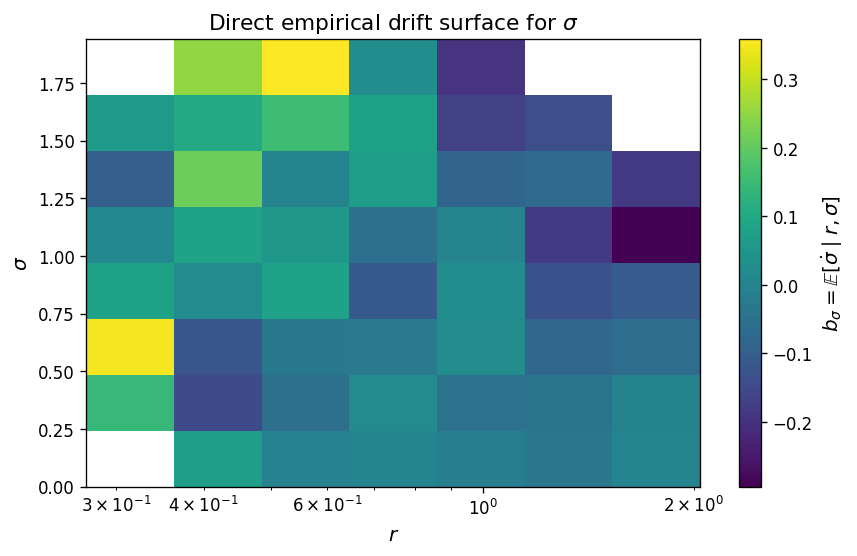

saved /mnt/data/figs_generator_diagnostics_v11/source_surface.png


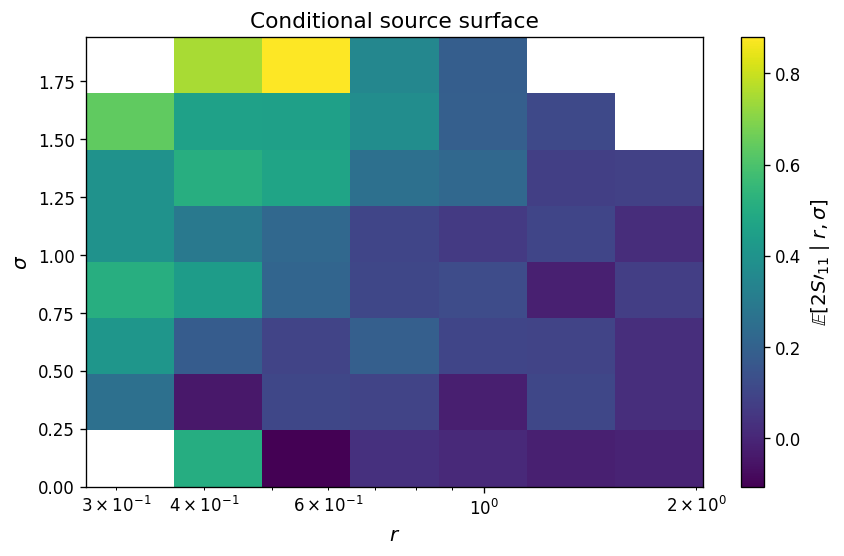

saved /mnt/data/figs_generator_diagnostics_v11/residual_surface.png


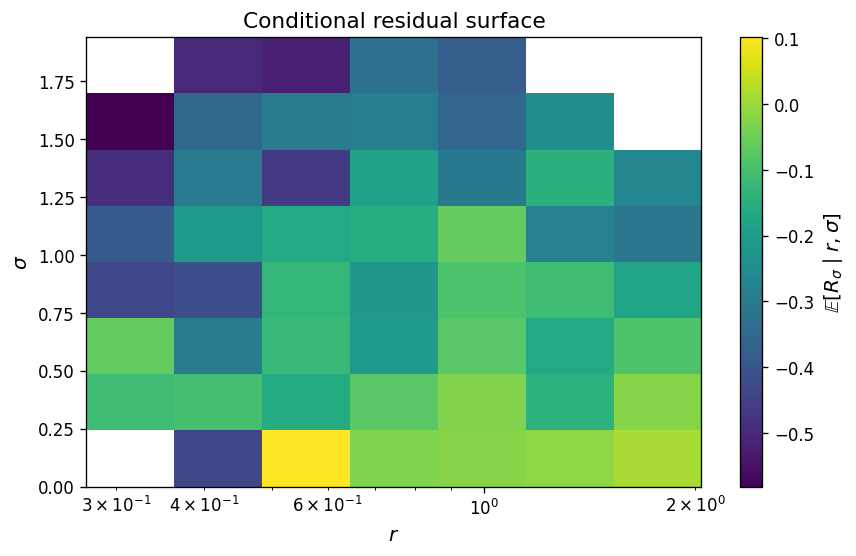

In [7]:
# 2D bins in r and sigma.
sigma_edges = np.linspace(0.0, np.nanpercentile(sigma_m, 99), 9)
sigma_centers = np.sqrt(sigma_edges[:-1]*sigma_edges[1:])
sigma_centers[~np.isfinite(sigma_centers)] = 0.5*(sigma_edges[:-1]+sigma_edges[1:])[~np.isfinite(sigma_centers)]

Rflat = r_m.ravel()
Sflat = sigma_m.ravel()
Dflat = sigma_dot.ravel()
Srcflat = source_sigma.ravel()
Resflat = R_sigma.ravel()

b_sigma = np.full((n_bins, len(sigma_centers)), np.nan)
b_source = np.full_like(b_sigma, np.nan)
b_resid = np.full_like(b_sigma, np.nan)
counts2 = np.zeros_like(b_sigma, dtype=int)

ridx = np.digitize(Rflat, r_edges)-1
sidx = np.digitize(Sflat, sigma_edges)-1
for i in range(n_bins):
    for j in range(len(sigma_centers)):
        sel = (ridx == i) & (sidx == j) & np.isfinite(Dflat)
        counts2[i,j] = np.count_nonzero(sel)
        if counts2[i,j] >= 25:
            b_sigma[i,j] = np.nanmean(Dflat[sel])
            b_source[i,j] = np.nanmean(Srcflat[sel])
            b_resid[i,j] = np.nanmean(Resflat[sel])

print('sigma_edges:', sigma_edges)
print('2D bin counts min/max:', np.nanmin(counts2), np.nanmax(counts2))

# Heatmap of empirical sigma drift.
plt.figure(figsize=(7.4,4.8))
X, Y = np.meshgrid(r_centers, sigma_centers, indexing='ij')
mesh = plt.pcolormesh(r_edges, sigma_edges, b_sigma.T, shading='auto')
plt.xscale('log')
plt.colorbar(mesh, label=r'$b_\sigma=\mathbb{E}[\dot\sigma\mid r,\sigma]$')
plt.xlabel(r'$r$')
plt.ylabel(r'$\sigma$')
plt.title('Direct empirical drift surface for $\sigma$')
savefig('b_sigma_surface')
plt.show()

plt.figure(figsize=(7.4,4.8))
mesh = plt.pcolormesh(r_edges, sigma_edges, b_source.T, shading='auto')
plt.xscale('log')
plt.colorbar(mesh, label=r'$\mathbb{E}[2S\prime_{11}\mid r,\sigma]$')
plt.xlabel(r'$r$')
plt.ylabel(r'$\sigma$')
plt.title('Conditional source surface')
savefig('source_surface')
plt.show()

plt.figure(figsize=(7.4,4.8))
mesh = plt.pcolormesh(r_edges, sigma_edges, b_resid.T, shading='auto')
plt.xscale('log')
plt.colorbar(mesh, label=r'$\mathbb{E}[R_\sigma\mid r,\sigma]$')
plt.xlabel(r'$r$')
plt.ylabel(r'$\sigma$')
plt.title('Conditional residual surface')
savefig('residual_surface')
plt.show()

## 7. Nullcline estimate in $\sigma$

A useful diagnostic is the empirical zero of

$$b_\sigma(r,\sigma)=0.$$

If a stable zero exists near $\sigma=O(1)$, then the empirical train has an effective shape generator with an attracting aspect ratio.  This is the object that a successful reduced model must reproduce.

estimated sigma nullcline: [1.1099112  0.10850325 0.66099912 0.01380777 0.52109409 0.
 0.        ]
empirical mean sigma: [1.0320443  1.08424356 1.11699837 1.04399789 1.03474263 0.83130819
 0.83511541]


saved /mnt/data/figs_generator_diagnostics_v11/sigma_mean_vs_nullcline.png


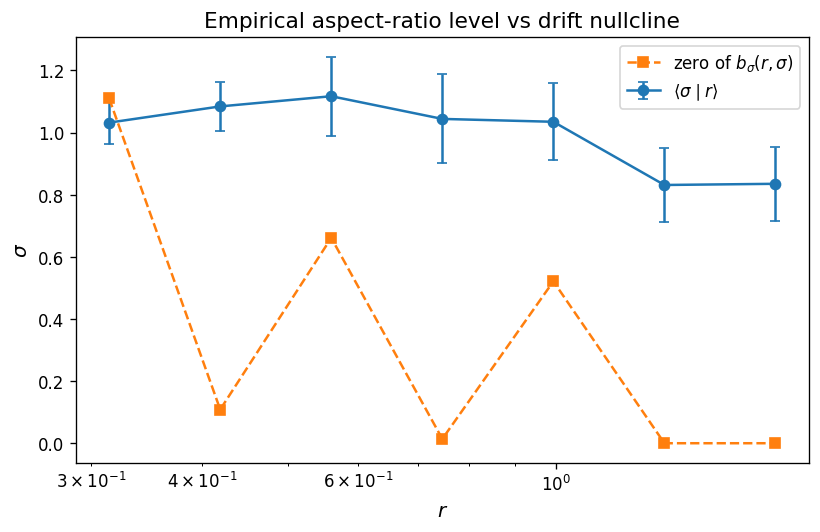

In [8]:
def zero_crossing(x, y):
    ok = np.isfinite(x) & np.isfinite(y)
    x = x[ok]
    y = y[ok]
    if len(x) < 2:
        return np.nan
    # Prefer sign changes from positive to negative as sigma increases.
    for a in range(len(x)-1):
        if y[a] == 0:
            return x[a]
        if y[a]*y[a+1] < 0:
            return x[a] - y[a]*(x[a+1]-x[a])/(y[a+1]-y[a])
    # If no sign change, return the point of smallest absolute drift.
    return x[np.nanargmin(np.abs(y))]

sigma_star = np.array([zero_crossing(sigma_centers, b_sigma[i]) for i in range(n_bins)])

print('estimated sigma nullcline:', sigma_star)
print('empirical mean sigma:', mean_sigma)

plt.figure(figsize=(7.0,4.6))
plt.errorbar(r_centers, mean_sigma, yerr=sem_sigma, marker='o', capsize=3, label=r'$\langle\sigma\mid r\rangle$')
plt.plot(r_centers, sigma_star, marker='s', linestyle='--', label=r'zero of $b_\sigma(r,\sigma)$')
plt.xscale('log')
plt.xlabel(r'$r$')
plt.ylabel(r'$\sigma$')
plt.title('Empirical aspect-ratio level vs drift nullcline')
plt.legend()
savefig('sigma_mean_vs_nullcline')
plt.show()

## 8. Volume budget check

The volume equation in the previous SDE was

$$\dot v=-\frac12\gamma(r).$$

This part should be much easier than the $\sigma$ equation, because it does not require orientation alignment.  We compare the empirical $\langle\dot v\mid r\rangle$ with the calibrated value $-\gamma(r)/2$.

mean v_dot: [0.36123358 0.29763699 0.25067878 0.16160997 0.11177412 0.13558151
 0.10222876]
model -gamma/2: [0.2249783  0.20195559 0.17439203 0.11433376 0.09026576 0.09700051
 0.08870603]


saved /mnt/data/figs_generator_diagnostics_v11/volume_budget_by_r.png


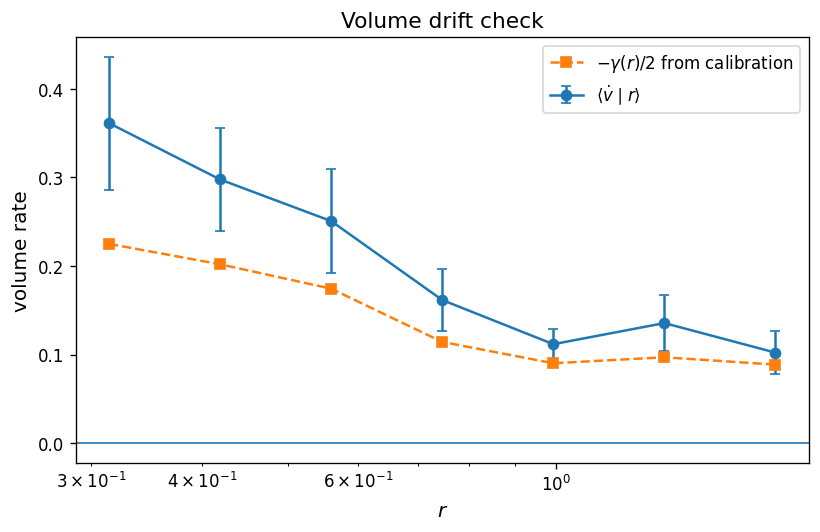

In [9]:
mean_vdot, sem_vdot, _, _ = binned_seed_mean(r_m, v_dot)
mean_vol_model, sem_vol_model, _, _ = binned_seed_mean(r_m, vol_model)

print('mean v_dot:', mean_vdot)
print('model -gamma/2:', -0.5*gamma_bins)

plt.figure(figsize=(7.0,4.6))
plt.axhline(0, linewidth=1)
plt.errorbar(r_centers, mean_vdot, yerr=sem_vdot, marker='o', capsize=3, label=r'$\langle\dot v\mid r\rangle$')
plt.plot(r_centers, -0.5*gamma_bins, marker='s', linestyle='--', label=r'$-\gamma(r)/2$ from calibration')
plt.xscale('log')
plt.xlabel(r'$r$')
plt.ylabel('volume rate')
plt.title('Volume drift check')
plt.legend()
savefig('volume_budget_by_r')
plt.show()

## 9. Export generator-diagnostic summary

The output file stores the empirical source, residual, alignment, drift-surface, and nullcline diagnostics.  This should be the input to the next reduced-model attempt.

In [10]:
out = Path('generator_diagnostics_v11_results.npz')
np.savez_compressed(
    out,
    r_edges=r_edges,
    r_centers=r_centers,
    sigma_edges=sigma_edges,
    sigma_centers=sigma_centers,
    mean_sigma=mean_sigma,
    sem_sigma=sem_sigma,
    mean_sigma_dot=mean_sdot,
    sem_sigma_dot=sem_sdot,
    mean_source=mean_source,
    sem_source=sem_source,
    mean_residual=mean_resid,
    sem_residual=sem_resid,
    mean_sink=mean_sink,
    sem_sink=sem_sink,
    mean_Sabs=mean_Sabs,
    sem_Sabs=sem_Sabs,
    mean_cos_alpha=mean_cosa,
    sem_cos_alpha=sem_cosa,
    mean_abs_cos_alpha=mean_abs_cosa,
    sem_abs_cos_alpha=sem_abs_cosa,
    mean_2S_cos_alpha=mean_2Scos,
    sem_2S_cos_alpha=sem_2Scos,
    b_sigma=b_sigma,
    b_source=b_source,
    b_residual=b_resid,
    counts2=counts2,
    sigma_star=sigma_star,
    mean_v_dot=mean_vdot,
    sem_v_dot=sem_vdot,
    gamma_bins=gamma_bins,
    kappa_bins=kappa_bins,
)
print('saved', out)

saved /mnt/data/generator_diagnostics_v11_results.npz


## 10. Interpretation guide

Use this checklist after running the notebook.

1. If $\langle 2S'_{11}\mid r\rangle$ is positive and comparable to the damping/residual terms, the failure of the marginal-OU SDE is explained: independent $M$ destroys the empirical alignment source.

2. If $\langle\cos\alpha\mid r\rangle$ is nonzero, the source is not just strain amplitude; it is an alignment effect between the MEE axis and the principal strain direction.

3. If $b_\sigma(r,\sigma)$ has a zero near the empirical $\langle\sigma\mid r\rangle$, then the empirical MEE train has a genuine attracting shape generator.  The next model should reproduce this generator, not only the marginal statistics of $M$.

4. A minimal next reduced model can be built in variables $(v,\sigma,|S|,\alpha,\omega)$, using

$$\dot\sigma=2|S|\cos\alpha + R_\sigma(r,\sigma),$$

where $R_\sigma$ is calibrated directly or modeled through a nonlinear damping/source closure.